In [5]:
# 파일 병합 테스트용

import pandas as pd
import glob
import os

# 경로 설정
data_dir = "./data/project2_data/"
file_paths = glob.glob(os.path.join(data_dir, "*.csv"))

merged_df = None

for path in file_paths:
    df = pd.read_csv(path)

    # 날짜 컬럼 자동 탐지
    date_col = None
    for col in df.columns:
        if 'time' in col.lower() or 'date' in col.lower():
            date_col = col
            break

    if date_col is None:
        print(f" 날짜 컬럼이 없어 건너뜀: {os.path.basename(path)}")
        continue  # 날짜 컬럼 없으면 병합 제외

    try:
        df[date_col] = pd.to_datetime(df[date_col])
    except Exception as e:
        print(f" 날짜 형식 변환 실패: {os.path.basename(path)} - {e}")
        continue

    df = df.sort_values(by=date_col)
    df = df.set_index(date_col)

    variable_prefix = os.path.splitext(os.path.basename(path))[0]
    df = df.add_prefix(variable_prefix + "_")

    df.index.name = "date"

    if merged_df is None:
        merged_df = df
    else:
        merged_df = pd.merge(merged_df, df, left_index=True, right_index=True, how="outer")

# 정렬 및 저장
if merged_df is not None:
    merged_df = merged_df.sort_index()
    merged_df.to_csv(os.path.join(data_dir, "merged_arctic_timeseries.csv"))
    print("병합 완료: merged_arctic_timeseries.csv")
else:
    print("병합할 수 있는 파일이 없습니다.")

병합 완료: merged_arctic_timeseries.csv


# EDA

In [56]:
import pandas as pd

# CSV 파일 불러오기
df = pd.read_csv("./data/project2_data/real_all_month_199101_202312.csv")

# 'time' 컬럼을 datetime 형식으로 변환하고 인덱스로 설정
df["time"] = pd.to_datetime(df["time"])
df.set_index("time", inplace=True)

# 기본 확인
print(df.head())

            sisnthick   sithick         so    thetao       vxo       vyo  \
time                                                                       
1991-01-01   0.177973  1.703898  27.320057 -1.490811 -0.013217 -0.027818   
1991-02-01   0.210169  1.849185  27.726406 -1.514051 -0.039828 -0.009575   
1991-03-01   0.218237  2.523808  28.389915 -1.551831 -0.008158  0.004591   
1991-04-01   0.260340  3.028774  28.640112 -1.566099 -0.010848  0.008725   
1991-05-01   0.202404  3.219205  28.395195 -1.552322 -0.027086  0.015708   

                 10u       10v          2t      sdlwrf      sdswrf  \
time                                                                 
1991-01-01  0.396382  0.136146  251.347715  197.342807    4.318931   
1991-02-01 -0.553790 -0.575898  250.347788  189.843379   29.518508   
1991-03-01 -0.059212 -0.038154  256.008667  201.612096   92.755665   
1991-04-01 -0.952358 -0.089430  267.802663  231.948397  185.653888   
1991-05-01 -0.739131  0.138950  278.282368  274

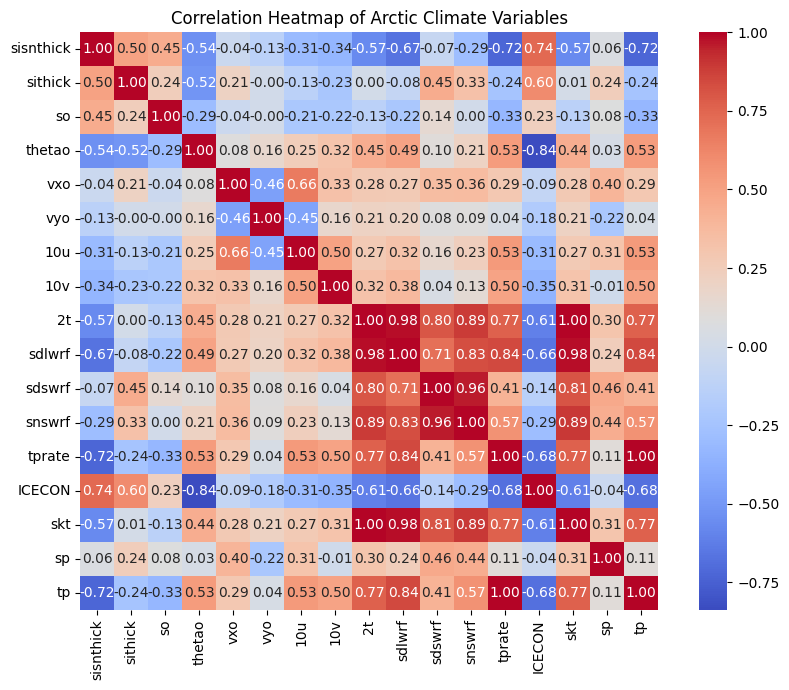

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

# 상관관계 계산
corr = df.corr()

# 히트맵 시각화 (작은 크기)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Arctic Climate Variables")
plt.tight_layout()
plt.show()

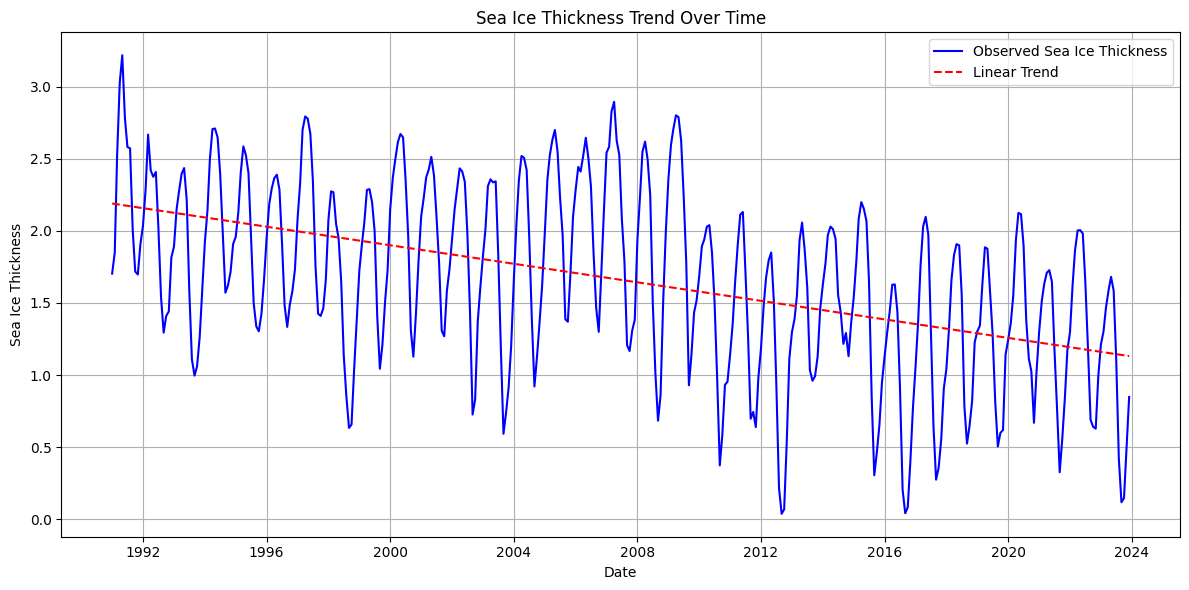

연간 평균 감소량 (단위/월): -0.00268


In [58]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# X: 시간 (숫자로 변환), y: 해빙두께
X = np.arange(len(df)).reshape(-1, 1)  # 시간 인덱스를 숫자로 변환
y = df["sithick"].values

# 회귀 모델 학습
model = LinearRegression()
model.fit(X, y)

# 추세선 예측
y_pred = model.predict(X)

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(df.index, y, label="Observed Sea Ice Thickness", color="blue")
plt.plot(df.index, y_pred, label="Linear Trend", color="red", linestyle="--")
plt.title("Sea Ice Thickness Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sea Ice Thickness")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 기울기 출력
slope = model.coef_[0]
print(f"연간 평균 감소량 (단위/월): {slope:.5f}")

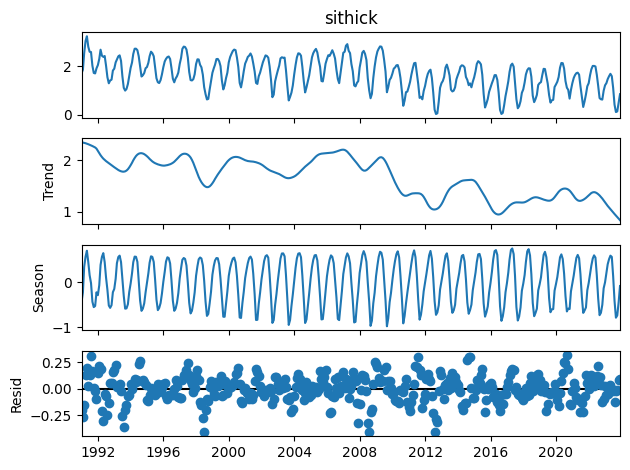

In [59]:
from statsmodels.tsa.seasonal import STL

# STL 분해
stl = STL(df["sithick"], period=12)  # 월별 데이터니까 period=12
res = stl.fit()

# 시각화
res.plot()
plt.tight_layout()
plt.show()

# 시계열

## 이상치 제거

In [60]:
# IQR 이상치 비율 계산
def calculate_outlier_ratio(df, columns):
    outlier_ratios = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # 이상치 비율 계산
        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        ratio = outliers / len(df)
        outlier_ratios[col] = ratio

    return pd.Series(outlier_ratios).sort_values(ascending=False)

# 수치형 변수 대상으로 실행
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
outlier_ratios = calculate_outlier_ratio(df, numeric_cols)

print(outlier_ratios)

thetao       0.166667
so           0.075758
ICECON       0.035354
vxo          0.017677
vyo          0.015152
sp           0.012626
10v          0.010101
10u          0.007576
tp           0.002525
tprate       0.002525
skt          0.000000
sisnthick    0.000000
snswrf       0.000000
sdswrf       0.000000
sdlwrf       0.000000
sithick      0.000000
2t           0.000000
dtype: float64


In [61]:
# 복사본 생성
df_clean = df.copy()

# 이상치 제거할 주요 수치형 컬럼 자동 선택
target_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()

# IQR 방식 이상치 제거 + 보간
for col in target_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 이상치를 NaN 처리
    df_clean[col] = df_clean[col].where((df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound))

# 결측값 선형 보간 (시간 기준)
df_clean.interpolate(method='linear', inplace=True)

# 남은 결측값 확인
print(df_clean.isnull().sum().sort_values(ascending=False))

sisnthick    0
sdlwrf       0
sp           0
skt          0
ICECON       0
tprate       0
snswrf       0
sdswrf       0
2t           0
sithick      0
10v          0
10u          0
vyo          0
vxo          0
thetao       0
so           0
tp           0
dtype: int64


### 이상치 제거 후 시각화

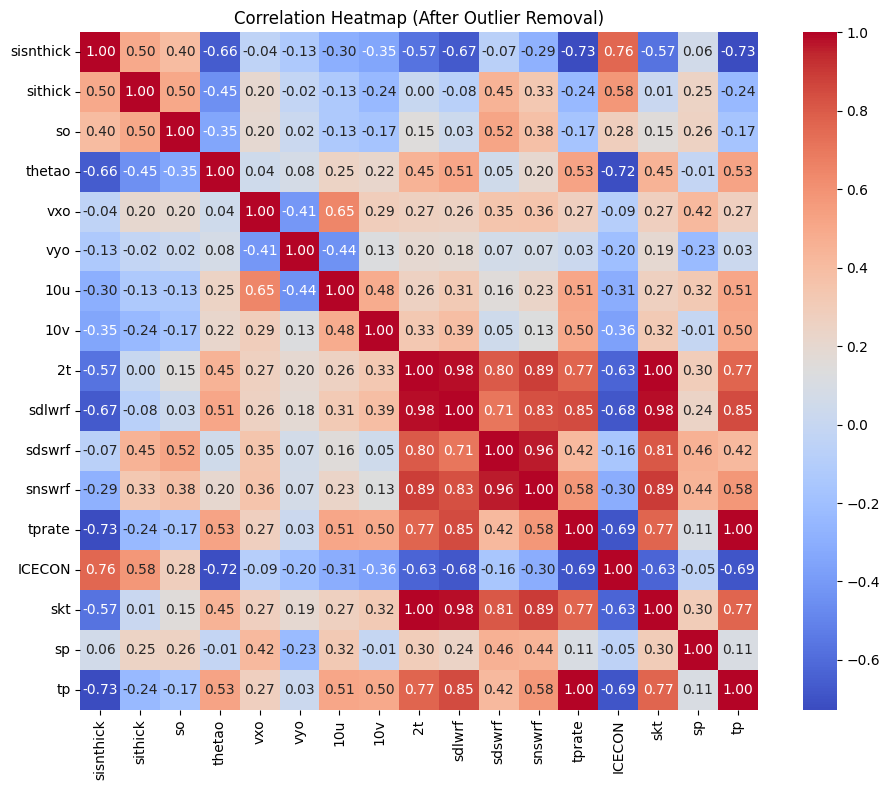

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

# 상관계수 계산
corr_clean = df_clean.corr()

# 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr_clean, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (After Outlier Removal)")
plt.tight_layout()
plt.show()

## ARIMA

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                sithick   No. Observations:                  396
Model:                 ARIMA(1, 1, 1)   Log Likelihood                  29.796
Date:                Fri, 25 Apr 2025   AIC                            -53.592
Time:                        10:31:01   BIC                            -41.655
Sample:                    01-01-1991   HQIC                           -48.862
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5123      0.064      7.983      0.000       0.386       0.638
ma.L1          0.2665      0.081      3.271      0.001       0.107       0.426
sigma2         0.0503      0.003     14.798      0.0

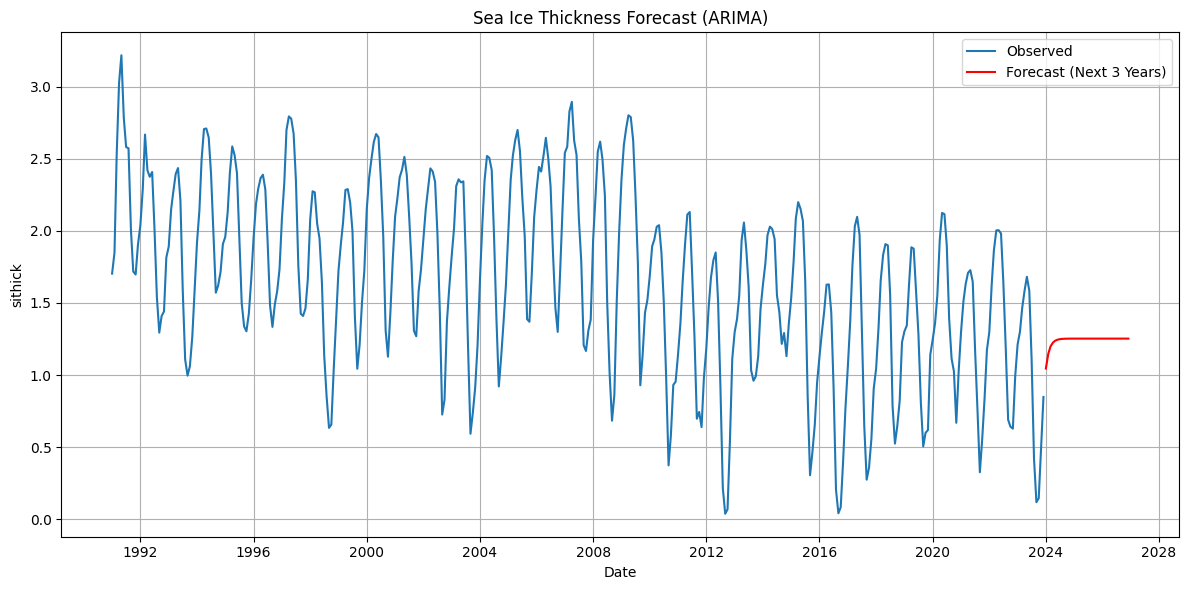

In [32]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# 분석 대상 설정
y = df_clean["sithick"]

# ARIMA 모델 학습 (p, d, q) = (1, 1, 1) 기본 시작
model = ARIMA(y, order=(1, 1, 1))
model_fit = model.fit()

# 요약 보기 (옵션)
print(model_fit.summary())

# 향후 36개월(3년) 예측
forecast = model_fit.forecast(steps=36)

# 예측 결과 시각화
plt.figure(figsize=(12, 6))
plt.plot(y, label="Observed")
plt.plot(forecast.index, forecast, label="Forecast (Next 3 Years)", color="red")
plt.title("Sea Ice Thickness Forecast (ARIMA)")
plt.xlabel("Date")
plt.ylabel("sithick")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## SARIMA

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


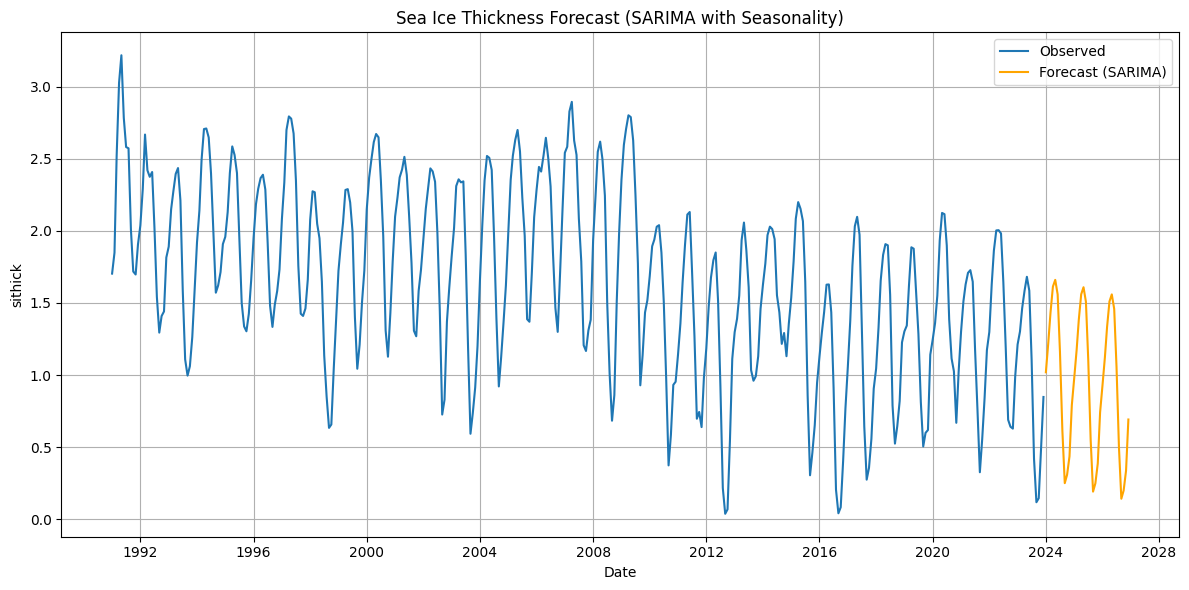

In [33]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

# SARIMA 모델 설정: (p,d,q)(P,D,Q,s)
# s=12은 월간 데이터의 계절 주기 (12개월=1년)
model = SARIMAX(df_clean["sithick"],
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)

# 모델 학습
model_fit = model.fit()

# 예측 (36개월 = 3년)
forecast = model_fit.forecast(steps=36)

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(df_clean["sithick"], label="Observed")
plt.plot(forecast.index, forecast, label="Forecast (SARIMA)", color="orange")
plt.title("Sea Ice Thickness Forecast (SARIMA with Seasonality)")
plt.xlabel("Date")
plt.ylabel("sithick")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### SARIMA 성능 결과

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 예측 범위를 기존 시계열로 확장하여 비교하고 싶을 경우 (예: 마지막 36개월 예측 vs 실제)
train = df_clean["sithick"][:-36]
test = df_clean["sithick"][-36:]

# SARIMA 모델 학습 후 테스트셋 예측
model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,36))
model_fit = model.fit()
pred = model_fit.forecast(steps=len(test))

# 성능 지표 계산
mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))
mape = np.mean(np.abs((test - pred) / test)) * 100

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


MAE  : 0.2438
RMSE : 0.2949
MAPE : 40.95%


## SARIMA 자동 튜닝 (pmdarima 라이브러리 사용)

In [35]:
import pmdarima as pm
from pmdarima import auto_arima

# 시계열 데이터
y = df_clean["sithick"]

# 자동 SARIMA 튜닝
auto_model = auto_arima(
    y,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    seasonal=True,
    m=12,                  # 계절 주기 (월간 데이터는 12)
    d=1, D=1,              # 차분 차수
    trace=True,            # 진행상황 출력
    error_action='ignore', # 에러 무시
    suppress_warnings=True,
    stepwise=True          # 빠르게 탐색
)

# 최적 모델 요약
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-192.630, Time=0.19 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-292.397, Time=0.34 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=-381.468, Time=0.87 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=-207.269, Time=0.17 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=-379.522, Time=1.39 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=-379.524, Time=2.50 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=-295.399, Time=0.37 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=-377.531, Time=2.47 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=-373.548, Time=0.48 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=-381.391, Time=1.07 sec
 ARIMA(0,1,2)(0,1,1)[12]             : AIC=-382.945, Time=0.83 sec
 ARIMA(0,1,2)(0,1,0)[12]             : AIC=-205.911, Time=0.18 sec
 ARIMA(0,1,2)(1,1,1)[12]             : AIC=-380.959, Time=1.40 sec
 ARIMA(0,1,2)(0,1,2)[12]             : AIC=-380.959, Time=2.87 sec
 ARIMA(0,1,2)(1,1,0

AttributeError: 'SARIMAX' object has no attribute 'summary'

### 성능 평가

In [ ]:
import matplotlib.pyplot as plt

# 이전에 분리한 테스트셋 기준 (최근 36개월)
train = df_clean["sithick"][:-36]
test = df_clean["sithick"][-36:]

# 튜닝된 SARIMAX 모델로 재학습 (앞에서 가져온 최적 order/seasonal_order 사용)
model = SARIMAX(train,
                order=auto_model.order,
                seasonal_order=auto_model.seasonal_order)
model_fit = model.fit()

# 예측
pred = model_fit.forecast(steps=len(test))

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label="Train Data", color="lightgray")
plt.plot(test.index, test, label="Actual (Test)", color="blue")
plt.plot(pred.index, pred, label="Predicted", color="orange", linestyle="--")
plt.title("Sea Ice Thickness Forecast vs Actual (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("sithick")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 실제값과 예측값 (test, pred는 앞에서 사용한 기준 그대로)
mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))
mape = np.mean(np.abs((test - pred) / test)) * 100

# 결과 출력
print(f" MAE  : {mae:.4f}")
print(f" RMSE : {rmse:.4f}")
print(f" MAPE : {mape:.2f}%")

## LSTM (Tensorflow 기반)

### 전처리

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 타겟 컬럼만 사용 (sithick)
values = df_clean["sithick"].values.reshape(-1, 1)

# 정규화 (LSTM은 정규화 필수!)
scaler = MinMaxScaler()
values_scaled = scaler.fit_transform(values)

# 슬라이딩 윈도우 생성
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

window_size = 12  # 12개월 기반 예측
X, y = create_sequences(values_scaled, window_size)

# Train/Test 분리
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

### 학습

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# LSTM 입력은 (samples, time_steps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# 모델 구성
model = Sequential([
    LSTM(64, activation='tanh', input_shape=(window_size, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.1, verbose=1)

### 평가

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 예측
y_pred_scaled = model.predict(X_test)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred_scaled)

# 평가
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100

print(f"LSTM MAE  : {mae:.4f}")
print(f"LSTM RMSE : {rmse:.4f}")
print(f"LSTM MAPE : {mape:.2f}%")

### 시각화

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_test_inv, label="Actual", color="blue")
plt.plot(y_pred_inv, label="Predicted", color="orange", linestyle="--")
plt.title("Sea Ice Thickness Forecast (LSTM)")
plt.xlabel("Time Step")
plt.ylabel("sithick")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## LSTM (다변량 시계열)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 사용할 변수
features = ["sithick", "2t", "ICECON", "thetao", "so"]
data = df_clean[features].dropna().copy()

# 정규화
scalers = {}
scaled_data = pd.DataFrame()

for col in features:
    scaler = MinMaxScaler()
    scaled_data[col] = scaler.fit_transform(data[[col]]).flatten()
    scalers[col] = scaler

def create_sequences(df, target_col, window_size):
    X, y = [], []
    for i in range(len(df) - window_size):
        X.append(df.iloc[i:i+window_size].values)
        y.append(df.iloc[i+window_size][target_col])
    return np.array(X), np.array(y)

window_size = 24  # 24개월 기준 예측
X, y = create_sequences(scaled_data, target_col="sithick", window_size=window_size)

# 데이터 분할
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

### 모델 구성 및 학습

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.1, verbose=1)

### 예측 & 평가

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred_scaled = model.predict(X_test)
sithick_scaler = scalers["sithick"]
y_test_inv = sithick_scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = sithick_scaler.inverse_transform(y_pred_scaled)

mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100

print(f"Multivariate LSTM MAE  : {mae:.4f}")
print(f"Multivariate LSTM RMSE : {rmse:.4f}")
print(f"Multivariate LSTM MAPE : {mape:.2f}%")

## 트리

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 불러오기
df = pd.read_csv("./data/project2_data/real_all_month_199101_202312.csv")  # 경로 맞춰줘

# 2. 파생 특성 생성
df["sithick_t-1"] = df["sithick"].shift(1)
df["2t_t-1"] = df["2t"].shift(1)
df["ICECON_t-1"] = df["ICECON"].shift(1)
df["delta_2t"] = df["2t"].diff()
df["delta_ICECON"] = df["ICECON"].diff()
df["delta_thetao"] = df["thetao"].diff()
df["sithick_roll3"] = df["sithick"].rolling(window=3).mean()
df["month"] = np.tile(np.arange(1, 13), len(df) // 12 + 1)[:len(df)]

# 3. 결측치 제거
df = df.dropna().reset_index(drop=True)

# 4. X, y 나누기
X = df.drop(columns=["sithick"])
y = df["sithick"]

# 5. 문자열 컬럼 제거 (혹시 있을 경우 대비)
X = X.select_dtypes(include=[np.number])

In [36]:
# 6. 학습 / 테스트 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. 모델 학습
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 8. 예측
y_pred = rf.predict(X_test)

# 9. 평가 지표
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 0.2227
RMSE : 0.2855
MAPE : 28.62%


In [37]:
# 10. 중요도 시각화
importances = rf.feature_importances_
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

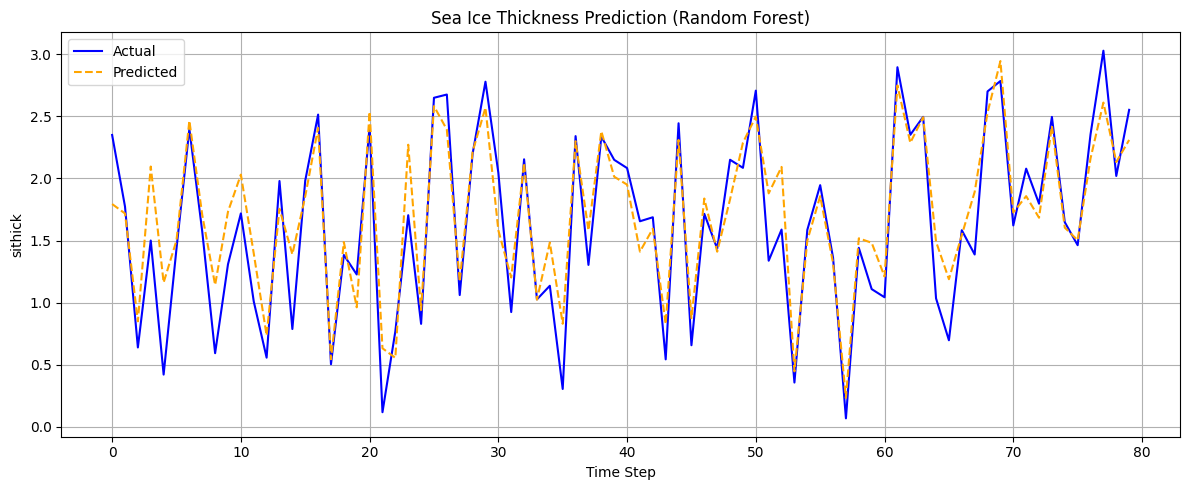

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="Actual", color="blue")
plt.plot(y_pred, label="Predicted", color="orange", linestyle="--")
plt.title("Sea Ice Thickness Prediction (Random Forest)")
plt.xlabel("Time Step")
plt.ylabel("sithick")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### XGBoost

MAE  : 0.1195
RMSE : 0.1471
MAPE : 20.22%


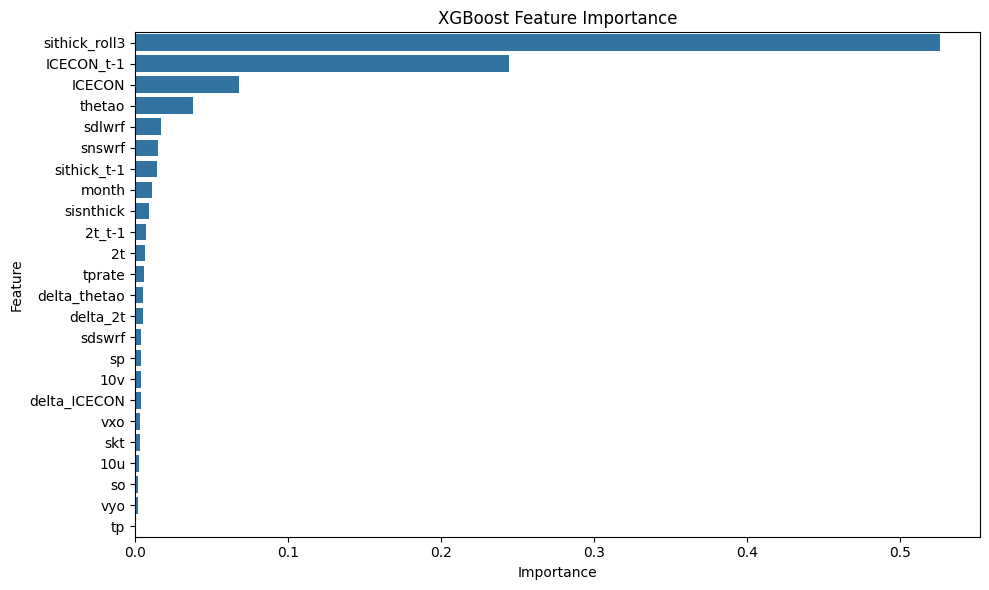

In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 불러오기
df = pd.read_csv("./data/project2_data/real_all_month_199101_202312.csv")

# 2. 파생 특성 생성
df["sithick_t-1"] = df["sithick"].shift(1)
df["2t_t-1"] = df["2t"].shift(1)
df["ICECON_t-1"] = df["ICECON"].shift(1)
df["delta_2t"] = df["2t"].diff()
df["delta_ICECON"] = df["ICECON"].diff()
df["delta_thetao"] = df["thetao"].diff()
df["sithick_roll3"] = df["sithick"].rolling(window=3).mean()
df["month"] = np.tile(np.arange(1, 13), len(df) // 12 + 1)[:len(df)]

# 3. 결측치 제거
df = df.dropna().reset_index(drop=True)

# 4. X, y 분리
X = df.drop(columns=["sithick"]).select_dtypes(include=[np.number])
y = df["sithick"]

# 5. 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. XGBoost 모델 정의 및 학습 (빠른 설정)
xgb = XGBRegressor(
    n_estimators=30,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    tree_method='hist'
)
xgb.fit(X_train, y_train)

# 7. 예측 및 평가
y_pred = xgb.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

# 8. 중요도 시각화
importances = xgb.feature_importances_
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

### XGBoost + SARIMA

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


보정 후 MAE  : 0.1207
보정 후 RMSE : 0.1486
보정 후 MAPE : 56.38%


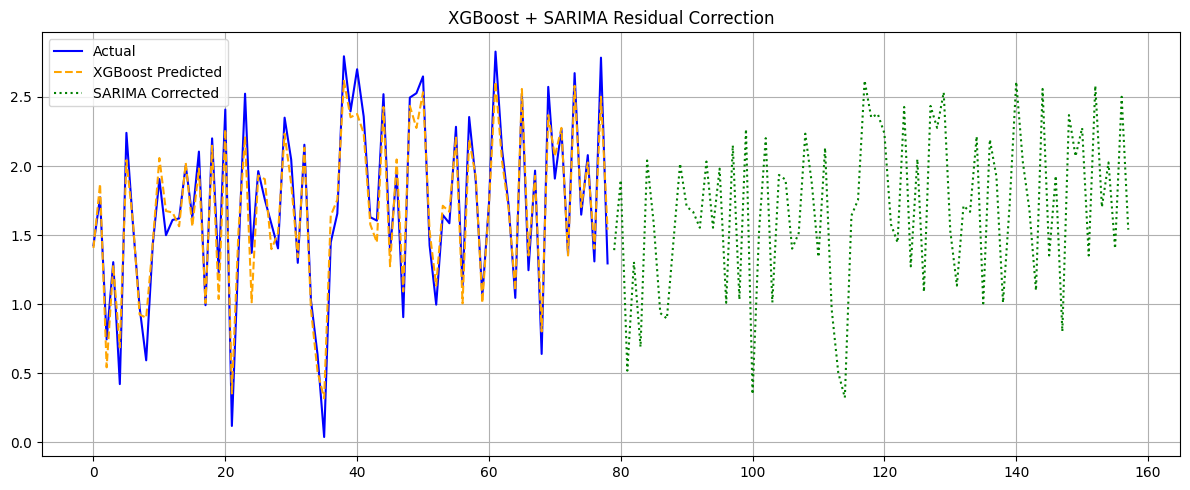

In [40]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv("./data/project2_data/real_all_month_199101_202312.csv")

# 2. 파생 특성 생성
df["sithick_t-1"] = df["sithick"].shift(1)
df["2t_t-1"] = df["2t"].shift(1)
df["ICECON_t-1"] = df["ICECON"].shift(1)
df["delta_2t"] = df["2t"].diff()
df["delta_ICECON"] = df["ICECON"].diff()
df["delta_thetao"] = df["thetao"].diff()
df["sithick_roll3"] = df["sithick"].rolling(window=3).mean()
df["month"] = np.tile(np.arange(1, 13), len(df) // 12 + 1)[:len(df)]
df = df.dropna().reset_index(drop=True)

# 3. X, y 설정
X = df.drop(columns=["sithick"]).select_dtypes(include=[np.number])
y = df["sithick"]

# 4. 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. XGBoost 모델 학습
xgb = XGBRegressor(n_estimators=30, learning_rate=0.1, max_depth=6, random_state=42, tree_method='hist')
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

# 6. 잔차 계산
residual = y_test.reset_index(drop=True) - y_pred

# 7. SARIMA 모델 적합 (잔차 모델링)
sarima_model = SARIMAX(residual, order=(1, 0, 1), seasonal_order=(1, 0, 1, 12))
sarima_result = sarima_model.fit(disp=False)
forecast_resid = sarima_result.forecast(steps=len(residual))

# 8. 예측값 보정
corrected_pred = y_pred + forecast_resid

# 9. 성능 평가
mae = mean_absolute_error(y_test, corrected_pred)
rmse = np.sqrt(mean_squared_error(y_test, corrected_pred))
mape = np.mean(np.abs((y_test - corrected_pred) / y_test)) * 100

print(f"보정 후 MAE  : {mae:.4f}")
print(f"보정 후 RMSE : {rmse:.4f}")
print(f"보정 후 MAPE : {mape:.2f}%")

# 10. 시각화
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="Actual", color="blue")
plt.plot(y_pred, label="XGBoost Predicted", linestyle="--", color="orange")
plt.plot(corrected_pred, label="SARIMA Corrected", linestyle=":", color="green")
plt.legend()
plt.title("XGBoost + SARIMA Residual Correction")
plt.grid(True)
plt.tight_layout()
plt.show()

### XGBoost + LSTM

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step
MAE  : 0.1350
RMSE : 0.1692
MAPE : 16.72%
R^2   : 0.8974


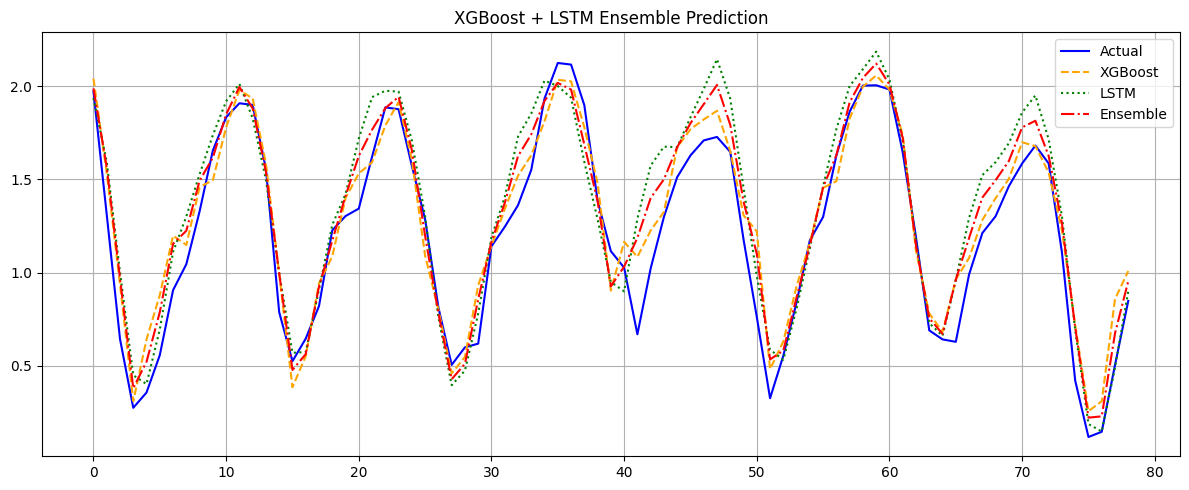

In [71]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv("./data/project2_data/real_all_month_199101_202312.csv")

# 2. 파생 변수 생성
df["sithick_t-1"] = df["sithick"].shift(1)
df["2t_t-1"] = df["2t"].shift(1)
df["ICECON_t-1"] = df["ICECON"].shift(1)
df["delta_2t"] = df["2t"].diff()
df["delta_ICECON"] = df["ICECON"].diff()
df["delta_thetao"] = df["thetao"].diff()
df["sithick_roll3"] = df["sithick"].rolling(window=3).mean()
df["month"] = np.tile(np.arange(1, 13), len(df) // 12 + 1)[:len(df)]

# 결측치 제거
df_clean = df.dropna().reset_index(drop=True)

# 3. X, y 분리
X = df_clean.drop(columns=["sithick"]).select_dtypes(include=[np.number])
y = df_clean["sithick"]

# 4. train/test 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 5. XGBoost 학습
xgb = XGBRegressor(n_estimators=30, learning_rate=0.1, max_depth=6, random_state=42, tree_method='hist')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# 6. LSTM을 위한 시계열 재구성
scaler_x = MinMaxScaler()
X_scaled = scaler_x.fit_transform(X)
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

def create_sequences(X, y, window=3):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i - window:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled)
split = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
y_train_seq, y_test_seq = y_seq[:split], y_seq[split:]

# 7. LSTM 모델 정의 및 학습
model = Sequential([
    LSTM(64, activation='relu', input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train_seq, y_train_seq, epochs=20, batch_size=16, verbose=0)

# 8. LSTM 예측
y_pred_lstm = model.predict(X_test_seq).flatten()
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm.reshape(-1, 1)).flatten()

# 9. 앙상블 (XGBoost와 예측 길이 맞추기)
offset = len(y_pred_xgb)
y_pred_lstm = y_pred_lstm[-offset:]
y_true = y_test.values[-offset:]
y_pred_ensemble = (y_pred_xgb + y_pred_lstm) / 2

# 10. 성능 평가
mae = mean_absolute_error(y_true, y_pred_ensemble)
rmse = np.sqrt(mean_squared_error(y_true, y_pred_ensemble))
mape = np.mean(np.abs((y_true - y_pred_ensemble) / y_true)) * 100
r2_stack = r2_score(y_true, y_pred_ensemble)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R^2   : {r2_stack:.4f}")

# 11. 시각화
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="Actual", color="blue")
plt.plot(y_pred_xgb, label="XGBoost", linestyle="--", color="orange")
plt.plot(y_pred_lstm, label="LSTM", linestyle=":", color="green")
plt.plot(y_pred_ensemble, label="Ensemble", linestyle="-.", color="red")
plt.legend()
plt.title("XGBoost + LSTM Ensemble Prediction")
plt.grid(True)
plt.tight_layout()
plt.show()

### 스테킹

STACKING MAE  : 0.1033
STACKING RMSE : 0.1306
STACKING MAPE : 11.75%
STACKING R²   : 0.9389


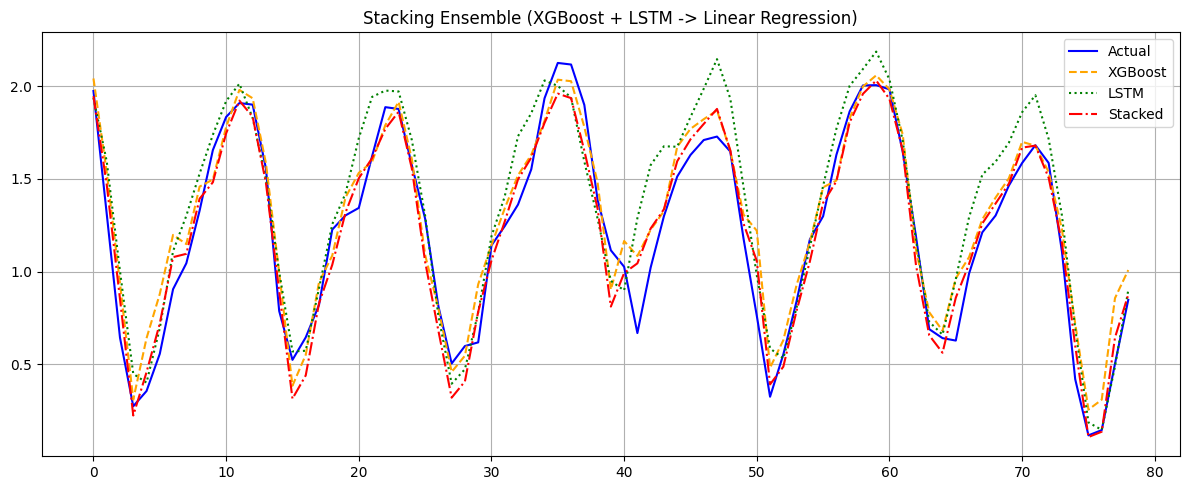

In [73]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. 예측값 준비 (이미 XGBoost, LSTM 학습 및 예측까지 끝났다고 가정)
# y_pred_xgb, y_pred_lstm, y_true 는 앞에서 사용한 것과 동일

# 스태킹용 입력 데이터 구성
X_stack = np.vstack((y_pred_xgb, y_pred_lstm)).T  # (N_samples, 2)
y_stack = y_true

# 2. 메타 모델 학습 (선형 회귀 사용)
meta_model = LinearRegression()
meta_model.fit(X_stack, y_stack)

# 3. 최종 예측
y_pred_stack = meta_model.predict(X_stack)

# 4. 성능 평가
mae_stack = mean_absolute_error(y_true, y_pred_stack)
rmse_stack = np.sqrt(mean_squared_error(y_true, y_pred_stack))
mape_stack = np.mean(np.abs((y_true - y_pred_stack) / y_true)) * 100
r2_stack = r2_score(y_true, y_pred_stack)

print(f"STACKING MAE  : {mae_stack:.4f}")
print(f"STACKING RMSE : {rmse_stack:.4f}")
print(f"STACKING MAPE : {mape_stack:.2f}%")
print(f"STACKING R²   : {r2_stack:.4f}")

# 시각화
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="Actual", color="blue")
plt.plot(y_pred_xgb, label="XGBoost", linestyle="--", color="orange")
plt.plot(y_pred_lstm, label="LSTM", linestyle=":", color="green")
plt.plot(y_pred_stack, label="Stacked", linestyle="-.", color="red")
plt.legend()
plt.title("Stacking Ensemble (XGBoost + LSTM -> Linear Regression)")
plt.grid(True)
plt.tight_layout()
plt.show()

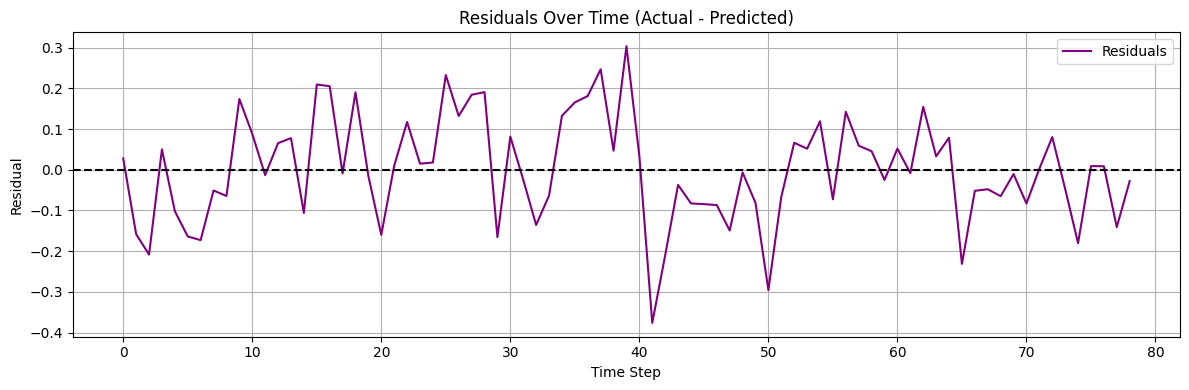

In [74]:
residuals = y_true - y_pred_stack

plt.figure(figsize=(12, 4))
plt.plot(residuals, label="Residuals", color="purple")
plt.axhline(0, color='black', linestyle='--')
plt.title("Residuals Over Time (Actual - Predicted)")
plt.xlabel("Time Step")
plt.ylabel("Residual")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

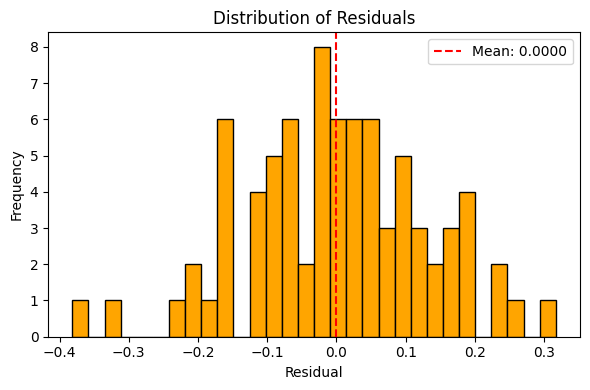

In [46]:
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30, color="orange", edgecolor="black")
plt.axvline(np.mean(residuals), color='red', linestyle='--', label=f"Mean: {np.mean(residuals):.4f}")
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

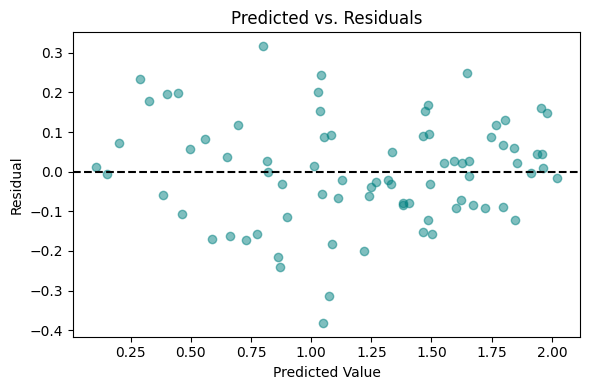

In [48]:
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_stack, residuals, alpha=0.5, color="teal")
plt.axhline(0, color='black', linestyle='--')
plt.title("Predicted vs. Residuals")
plt.xlabel("Predicted Value")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()